# Análisis del caso de uso: refrigeración de un data center

Este cuaderno carga la última ejecución de `python -m pso.run_scripts.run_datacenter_case` y produce todas las tablas y figuras que comparan la configuración baseline contra la encontrada por el PSO.

## 1. Carga de la última ejecución

Localizamos `pso/results/` desde el directorio de trabajo del cuaderno y cogemos la carpeta `datacenter_*` más reciente que tenga `config.json` y `convergence.csv` dentro.

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from pso.use_case.scenario import create_default_datacenter_scenario
from pso.use_case.encoding import phys_to_norm
from pso.use_case.objective import evaluate_solution


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "pso" / "__init__.py").exists() and candidate.name != "pso":
            return candidate


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_ROOT = PROJECT_ROOT / "pso" / "results"

candidates = sorted(
    [
        p for p in RESULTS_ROOT.glob("datacenter_*")
        if (p / "config.json").exists() and (p / "convergence.csv").exists()
    ],
    reverse=True,
)

RUN_DIR = candidates[0]
print(f"Using: {RUN_DIR.name}")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

Using: datacenter_20260528_162901


## 2. Reconstrucción del escenario y de las dos soluciones

Leemos el `config.json` para sacar la seed y la solución del PSO en unidades físicas. Con la seed reconstruimos el escenario (cargas térmicas, posiciones, matrices de influencia), que es idéntico al que se usó en la ejecución original.

A partir de ahí evaluamos las dos configuraciones con `evaluate_solution`, que devuelve fitness, energía desglosada, estadísticas térmicas y conteos de seguridad.

In [2]:
config = json.loads((RUN_DIR / "config.json").read_text(encoding="utf-8"))
seed = config["seed"]
pso_solution = config["pso_solution"]

scenario = create_default_datacenter_scenario(seed=seed)

# Baseline configuration (already stored inside the scenario)
x_baseline_norm = phys_to_norm(scenario.baseline_x_phys, scenario)
baseline = evaluate_solution(x_baseline_norm, scenario)

# PSO solution: reconstruct the physical vector from config.json and normalise it
x_pso_phys = np.concatenate(
    [[pso_solution["t_set"]], pso_solution["fan_speeds"], pso_solution["zone_airflows"]]
)
x_pso_norm = phys_to_norm(x_pso_phys, scenario)
pso = evaluate_solution(x_pso_norm, scenario)

print(f"Scenario | n_racks={scenario.n_racks}, n_fans={scenario.n_fans}, n_zones={scenario.n_zones}, dim={scenario.dim}")
print(f"Seed     | {seed}")
print(f"PSO ran  | {config['pso_iterations']} iterations in {config['pso_runtime_seconds']:.3f} s")

Scenario | n_racks=20, n_fans=4, n_zones=4, dim=9
Seed     | 42
PSO ran  | 224 iterations in 0.518 s


## 3. Comparativa global: baseline vs PSO

Tabla compacta con las métricas que importan:

- **fitness**: lo que minimiza el PSO. Combina energía relativa al baseline más cinco penalizaciones (seguridad, hotspot, sobreenfriamiento, balance térmico, cambio respecto al baseline).
- **total energy**: consumo total en unidades arbitrarias del modelo.
- **max/mean/std temperature**: estadísticas térmicas de los 20 racks.
- **unsafe racks**: cuántos superan T_safe = 27 °C.
- **hotspots**: cuántos superan T_hot = 30 °C

In [3]:
metrics = [
    "fitness", "total_energy", "chiller_energy", "fan_energy", "airflow_energy",
    "mean_temperature", "max_temperature", "min_temperature", "std_temperature",
    "unsafe_racks", "hotspots", "overcooled_racks",
]
comparison = pd.DataFrame(
    {"baseline": [baseline[m] for m in metrics], "PSO": [pso[m] for m in metrics]},
    index=metrics,
)
comparison["delta"] = comparison["PSO"] - comparison["baseline"]
comparison["delta_pct"] = 100 * comparison["delta"] / comparison["baseline"].replace(0, np.nan)

energy_savings = (baseline["total_energy"] - pso["total_energy"]) / baseline["total_energy"] * 100
print(f"Energy savings vs baseline: {energy_savings:+.2f}%\n")
display(comparison.round(4))

Energy savings vs baseline: +16.99%



,baseline,PSO,delta,delta_pct
fitness,1.3336,1.1378,-0.1959,-14.6874
total_energy,52.5535,43.6229,-8.9306,-16.9933
chiller_energy,40.0000,34.3743,-5.6257,-14.0641
fan_energy,8.4375,4.0927,-4.3448,-51.4938
airflow_energy,4.1160,5.1559,1.0399,25.2641
mean_temperature,24.6318,26.4704,1.8387,7.4646
max_temperature,25.3281,27.0091,1.6811,6.6372
min_temperature,23.6977,25.7330,2.0353,8.5885
std_temperature,0.4084,0.3670,-0.0414,-10.1392
unsafe_racks,0.0000,1.0000,1.0000,NaN


- El PSO baja el fitness respecto al baseline, lo cual significa que ha encontrado una configuración mejor según la función objetivo.
- El ahorro energético total es del orden del 15-20 % en esta ejecución. La mayor parte viene de bajar los ventiladores (la ley cúbica castiga muchísimo las velocidades altas).
- El PSO acepta subir un poco la temperatura media de los racks porque la penalización es suave hasta `T_safe = 27 °C`. Si llega a tocar ese borde es comportamiento esperado del optimizador apurando el trade-off.
- `hotspots` debe ser 0 en ambas configuraciones: la penalización dura impide al PSO cruzar `T_hot = 30 °C`.

## 4. Curva de convergencia

Cómo evoluciona el mejor fitness encontrado por el enjambre iteración a iteración. La curva debe ser monótona no creciente (el motor PSO lo garantiza). La velocidad de caída inicial dice cuánto margen había para mejorar el baseline.

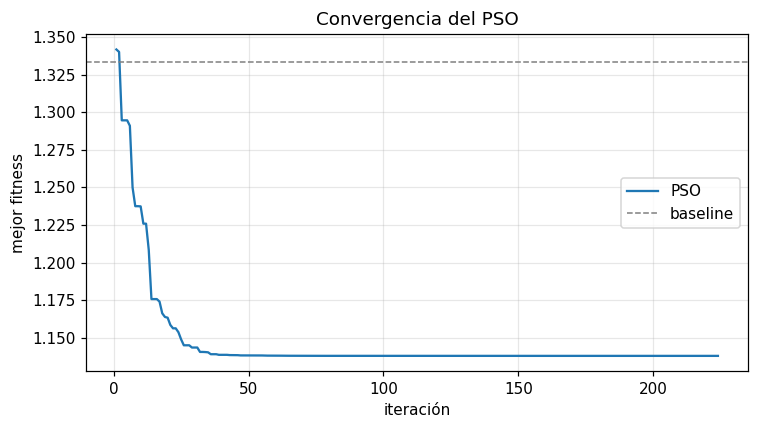

Fitness inicial : 1.3420
Fitness final   : 1.1378
Iteraciones     : 224


In [4]:
convergence = pd.read_csv(RUN_DIR / "convergence.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(convergence["iteration"], convergence["best_fitness"], color="tab:blue", label="PSO")
ax.axhline(baseline["fitness"], color="gray", linestyle="--", linewidth=1, label="baseline")
ax.set_xlabel("iteración")
ax.set_ylabel("mejor fitness")
ax.set_title("Convergencia del PSO")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Fitness inicial : {convergence['best_fitness'].iloc[0]:.4f}")
print(f"Fitness final   : {convergence['best_fitness'].iloc[-1]:.4f}")
print(f"Iteraciones     : {len(convergence)}")

- La caída más fuerte ocurre en las primeras decenas de iteraciones. El PSO encuentra rápido configuraciones razonables.
- A partir de cierto punto la curva se aplana. El PSO se queda refinando localmente.
- Que la curva final esté por debajo de la línea del baseline confirma que la búsqueda fue útil.
- Si el PSO terminara muy por encima del número de iteraciones máximas significaría que ha cortado por `patience` (no había mejoras significativas en bastantes iteraciones seguidas).

## 5. Desglose energético

El consumo total se reparte entre el chiller (que crece exponencialmente al bajar el setpoint), los ventiladores (ley cúbica con la velocidad) y los caudales por zona (también cúbico). Comparar el desglose explica por dónde está ahorrando el PSO.

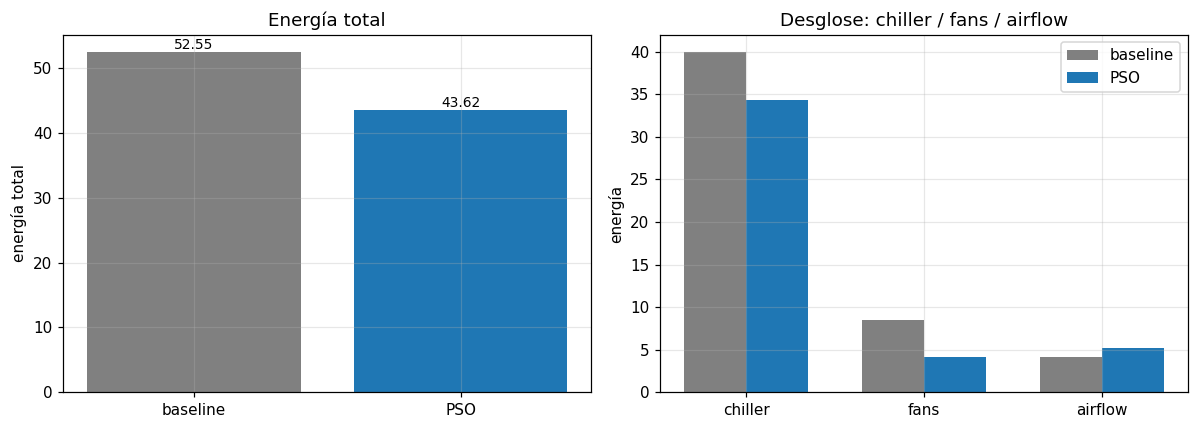

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Total energy
ax = axes[0]
labels = ["baseline", "PSO"]
values = [baseline["total_energy"], pso["total_energy"]]
bars = ax.bar(labels, values, color=["gray", "tab:blue"])
ax.set_ylabel("energía total")
ax.set_title("Energía total")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

# Energy breakdown
ax = axes[1]
components = ["chiller_energy", "fan_energy", "airflow_energy"]
component_labels = ["chiller", "fans", "airflow"]
x = np.arange(len(component_labels))
width = 0.35
ax.bar(x - width / 2, [baseline[c] for c in components], width, label="baseline", color="gray")
ax.bar(x + width / 2, [pso[c] for c in components], width, label="PSO", color="tab:blue")
ax.set_xticks(x)
ax.set_xticklabels(component_labels)
ax.set_ylabel("energía")
ax.set_title("Desglose: chiller / fans / airflow")
ax.legend()

plt.tight_layout()
plt.show()

- El PSO baja un poco el setpoint manteniéndolo dentro del rango razonable.
- El ahorro grande aparece en `fan_energy`, bajar las velocidades del 0.75 baseline al rango 0.55-0.65 se nota mucho porque el consumo va al cubo.
- `airflow_energy` puede subir ligeramente si el PSO compensa los ventiladores más lentos redistribuyendo caudal por zonas. Sigue saliéndole rentable por el balance global.

## 6. Mapas térmicos

Temperatura de los 20 racks dispuestos en la rejilla 4x5. Permite ver dónde están los puntos calientes y si el PSO redistribuye mejor el calor.

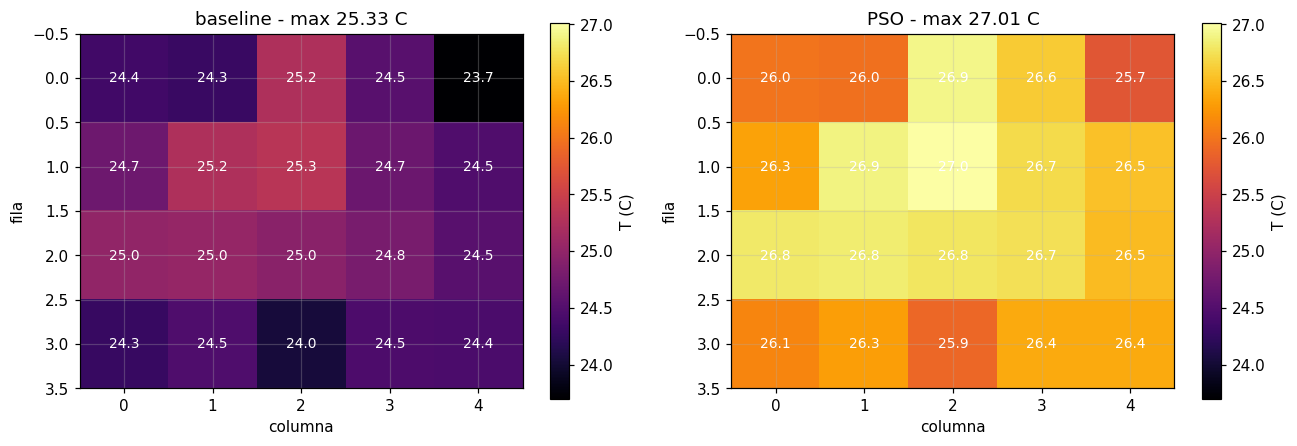

In [6]:
def heatmap_grid(temperatures: np.ndarray, scenario):
    rows, cols = scenario.grid_shape
    grid = np.zeros((rows, cols))
    for r, (i, j) in enumerate(scenario.rack_positions.astype(int)):
        grid[i, j] = temperatures[r]
    return grid


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Use a common color scale so the two heatmaps are visually comparable
vmin = min(baseline["temperatures"].min(), pso["temperatures"].min())
vmax = max(baseline["temperatures"].max(), pso["temperatures"].max())

for ax, (name, sol) in zip(axes, [("baseline", baseline), ("PSO", pso)]):
    grid = heatmap_grid(sol["temperatures"], scenario)
    im = ax.imshow(grid, cmap="inferno", aspect="equal", vmin=vmin, vmax=vmax)
    ax.set_title(f"{name} - max {sol['max_temperature']:.2f} C")
    ax.set_xlabel("columna")
    ax.set_ylabel("fila")
    for i in range(scenario.grid_shape[0]):
        for j in range(scenario.grid_shape[1]):
            ax.text(j, i, f"{grid[i, j]:.1f}", ha="center", va="center", color="white", fontsize=9)
    fig.colorbar(im, ax=ax, label="T (C)")

plt.tight_layout()
plt.show()

- Los racks de las esquinas suelen estar más fríos porque están más cerca de los ventiladores.
- El patrón de calor cambia entre baseline y PSO: como el PSO baja la velocidad de los ventiladores y redistribuye el caudal por zonas, los gradientes se reorganizan.
- Comprueba visualmente que ningún rack en PSO se va por encima de `T_hot = 30 °C`. Si vieras alguna celda en torno a 27 °C, ese es un rack en el límite suave de seguridad. El PSO está apurando el margen pero sin romper la restricción dura.
- La escala de color es común a ambos mapas para que la comparación visual sea justa.

## 7. Variables óptimas vs baseline

Comparativa de las 9 variables de decisión: setpoint del chiller, velocidades de los 4 ventiladores y caudales de las 4 zonas. Útil para ver qué hace el PSO con cada actuador.

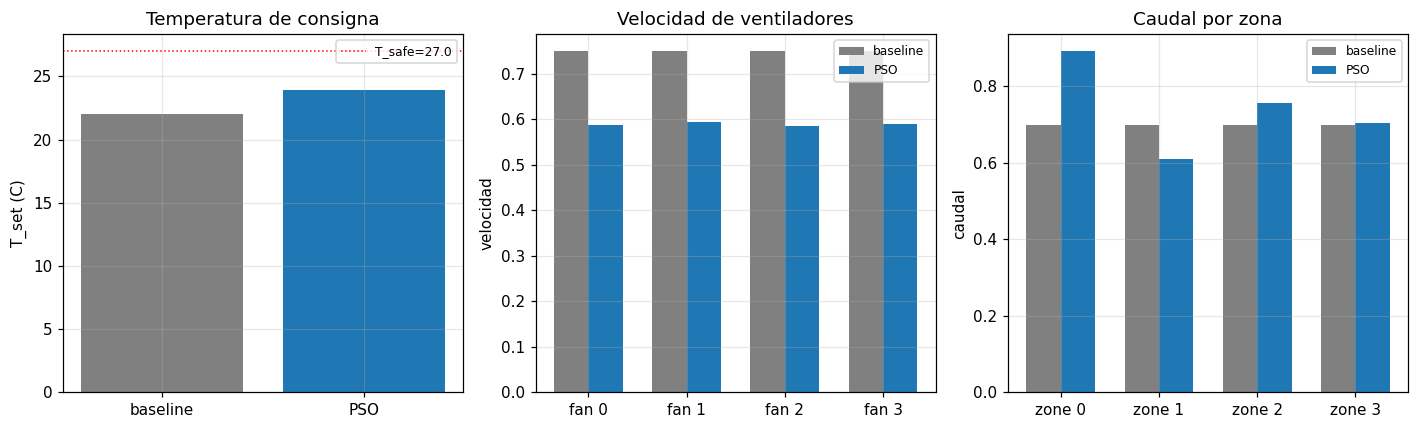

In [7]:
baseline_fans = scenario.baseline_x_phys[1:1 + scenario.n_fans]
baseline_zones = scenario.baseline_x_phys[1 + scenario.n_fans:]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
width = 0.35

# Setpoint
ax = axes[0]
ax.bar(["baseline", "PSO"], [scenario.baseline_x_phys[0], pso["t_set"]], color=["gray", "tab:blue"])
ax.set_ylabel("T_set (C)")
ax.set_title("Temperatura de consigna")
ax.axhline(scenario.t_safe, color="red", linestyle=":", linewidth=1, label=f"T_safe={scenario.t_safe}")
ax.legend(fontsize=8)

# Fan speeds
ax = axes[1]
x_fans = np.arange(scenario.n_fans)
ax.bar(x_fans - width / 2, baseline_fans, width, label="baseline", color="gray")
ax.bar(x_fans + width / 2, pso["fan_speeds"], width, label="PSO", color="tab:blue")
ax.set_xticks(x_fans)
ax.set_xticklabels([f"fan {i}" for i in range(scenario.n_fans)])
ax.set_ylabel("velocidad")
ax.set_title("Velocidad de ventiladores")
ax.legend(fontsize=8)

# Zone airflows
ax = axes[2]
x_zones = np.arange(scenario.n_zones)
ax.bar(x_zones - width / 2, baseline_zones, width, label="baseline", color="gray")
ax.bar(x_zones + width / 2, pso["zone_airflows"], width, label="PSO", color="tab:blue")
ax.set_xticks(x_zones)
ax.set_xticklabels([f"zone {i}" for i in range(scenario.n_zones)])
ax.set_ylabel("caudal")
ax.set_title("Caudal por zona")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Lectura rápida:**

- **Setpoint**: el PSO tiende a subirlo un poco respecto al baseline (22 °C), porque bajar T_set cuesta exponencialmente al chiller y el margen de seguridad lo permite.
- **Ventiladores**: el patrón típico es bajarlos todos respecto al baseline. La ley cúbica hace que un pequeño recorte se traduzca en ahorro grande.
- **Caudales por zona**: aquí es donde el PSO se vuelve interesante. Suele asignar más caudal a las zonas con racks de mayor carga térmica, redistribuyendo recursos en lugar de subir todo uniformemente.
- Si las cuatro barras del PSO de los ventiladores son casi iguales, significa que la influencia espacial es simétrica y el modelo no premia diferenciarlos. Cuando los caudales por zona varían más entre ellos, es porque las zonas sí tienen cargas distintas (por la heterogeneidad introducida en la seed).

## 8. Conclusiones

- El PSO consigue reducir el consumo energético respecto al baseline aprovechando la ley cúbica de los ventiladores y subiendo ligeramente el setpoint.
- La penalización combinada (safe, hotspot, balance, change) impide que el optimizador encuentre soluciones "baratas" pero peligrosas. Si en algún rack se ven temperaturas en el borde de `T_safe`, es comportamiento esperado: el optimizador apura el trade-off.
- El modelo está intencionadamente simplificado (no es CFD, no hay dinámica temporal, no hay efectos pasillo-caliente/frío). Sirve para mostrar la estructura típica de un problema real, no para dimensionar una instalación.
- Para resultados más conservadores se puede subir `lambda_safe` en `scenario.py`. Para apurar más el ahorro se puede bajar `lambda_change`, que es el término que ata la solución al baseline.